In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from sparrow import Protein
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
construct_stats = pd.read_csv('constructs_df.csv', index_col=0)

construct_stats['construct'] = construct_stats['construct'].astype(str)

In [3]:
# Function to calculate sequence features and predictions using sparrow
def calculate_sparrow_features(seqs_df):
    features = []
    for idx, row in seqs_df.iterrows():
        seq = row['sequence']
        construct = row['construct']
        protein = Protein(seq)
        
        # Calculate features
        f_positive = protein.fraction_positive
        f_negative = protein.fraction_negative
        aro = protein.fraction_aromatic
        ali = protein.fraction_aliphatic
        polar = protein.fraction_polar
        proline = protein.fraction_proline
        scd = protein.SCD                    # Uppercase SCD
        shd = protein.SHD                    # Uppercase SHD
        ncpr = protein.NCPR                  # Uppercase NCPR
        fcr = protein.FCR                    # Uppercase FCR
        hydrophobicity = protein.hydrophobicity
        kappa = protein.kappa
        
        # Predictions
        rg = protein.predictor.radius_of_gyration()
        re = protein.predictor.end_to_end_distance()
        mean_disorder = np.mean(protein.predictor.disorder())
        asphericity = protein.predictor.asphericity()
        scaling_exp = protein.predictor.scaling_exponent()
        prefactor = protein.predictor.prefactor()
        coil = protein.predictor.dssp_coil()
        extended = protein.predictor.dssp_extended()
        helicity = protein.predictor.dssp_helicity()
        
        features.append({
            'construct': construct,
            'f_positive': f_positive,
            'f_negative': f_negative,
            'aro': aro,
            'ali': ali,
            'polar': polar,
            'proline': proline,
            'scd': scd,
            'shd': shd,
            'NCPR': ncpr,
            'FCR': fcr,
            'hydrophobicity': hydrophobicity,
            'kappa': kappa,
            'rg': rg,
            're': re,
            'mean_disorder': mean_disorder,
            'asphericity': asphericity,
            'scaling_exponent': scaling_exp,
            'prefactor': prefactor,
            'coil': coil,
            'extended': extended,
            'helicity': helicity
        })
    return pd.DataFrame(features)

# Calculate features and predictions, then merge with construct_stats
sparrow_features = calculate_sparrow_features(construct_stats)
construct_stats = construct_stats.merge(sparrow_features, on='construct', how='left')

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


In [4]:
construct_stats['construct'] = construct_stats['construct'].astype(int)

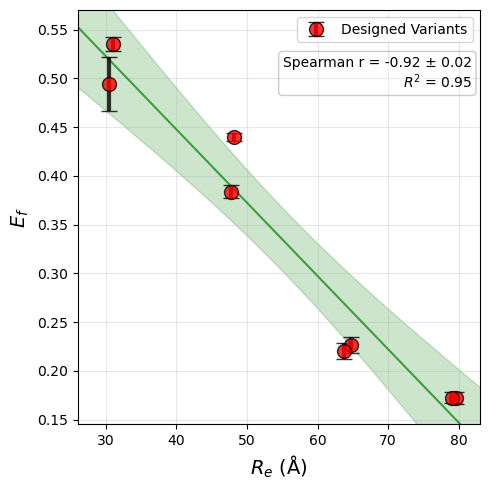

In [5]:
# Filter for construct > 34
designed_constructs = construct_stats[construct_stats['construct'] > 34].copy()

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_y = []
    
    for idx, row in designed_constructs.iterrows():
        # Sample from normal distribution for Ef_cell only (Re stays constant)
        sampled_y_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation for this iteration
    spearman_r_sample, _ = sp_stats.spearmanr(designed_constructs['re'], sampled_y)
    spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

# Linear regression
def linear_function(x, slope, intercept):
    return slope * x + intercept

x_data = designed_constructs['re'].values
y_data = designed_constructs['Ef_cell'].values

popt, pcov = curve_fit(linear_function, x_data, y_data)
slope, intercept = popt

# Calculate R-squared and residual standard error
residuals = y_data - linear_function(x_data, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
n = len(x_data)
dof = n - 2
residual_std_error = np.sqrt(ss_res / dof)
t_val = t_dist.ppf(0.975, dof)

# Generate line for plotting
x_fit = np.linspace(-20, 90, 200)
y_fit = linear_function(x_fit, slope, intercept)

# 95% confidence interval for the prediction
se_line = residual_std_error * np.sqrt(1/n + (x_fit - np.mean(x_data))**2 / np.sum((x_data - np.mean(x_data))**2))
y_upper = y_fit + t_val * se_line
y_lower = y_fit - t_val * se_line

# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot confidence band first
ax.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2, zorder=1)

# Plot fit line
ax.plot(x_fit, y_fit, color='green', linewidth=1.5, alpha=0.7, zorder=2)

# Plot data points
ax.errorbar(designed_constructs['re'], designed_constructs['Ef_cell'], 
           yerr=designed_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='red', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Designed Variants', zorder=3)

plt.xlim(26, 83)
plt.ylim(.145, .57)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

ax.text(0.98, 0.89, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.tight_layout()
#plt.savefig('Figure_graphs/Fig3/Ef_vs_Re_designed.svg')
plt.show()

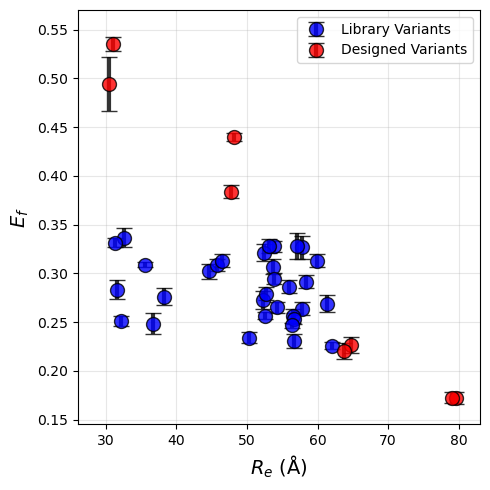

In [6]:
# Separate constructs into library (<34) and designed (>34)
library_constructs = construct_stats[construct_stats['construct'] < 34].copy()
designed_constructs = construct_stats[construct_stats['construct'] > 34].copy()

# Combine all constructs for overall analysis
all_constructs = construct_stats[(construct_stats['construct'] < 34) | 
                                 (construct_stats['construct'] > 34)].copy()
# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot library constructs in blue
ax.errorbar(library_constructs['re'], library_constructs['Ef_cell'], 
           yerr=library_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='blue', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Library Variants', zorder=3)

# Plot designed constructs in red
ax.errorbar(designed_constructs['re'], designed_constructs['Ef_cell'], 
           yerr=designed_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='red', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Designed Variants', zorder=3)

plt.xlim(26, 83)
plt.ylim(.145, .57)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
#plt.savefig('Figure_graphs/Fig3/Ef_vs_Re_all.svg')
plt.show()

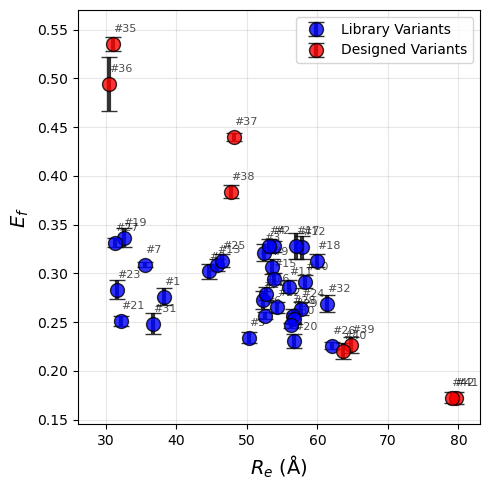

In [7]:
# Separate constructs into library (<34) and designed (>34)
library_constructs = construct_stats[construct_stats['construct'] < 34].copy()
designed_constructs = construct_stats[construct_stats['construct'] > 34].copy()

# Combine all constructs for overall analysis
all_constructs = construct_stats[(construct_stats['construct'] < 34) | 
                                 (construct_stats['construct'] > 34)].copy()
# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot library constructs in blue
ax.errorbar(library_constructs['re'], library_constructs['Ef_cell'], 
           yerr=library_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='blue', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Library Variants', zorder=3)

# Plot designed constructs in red
ax.errorbar(designed_constructs['re'], designed_constructs['Ef_cell'], 
           yerr=designed_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='red', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='Designed Variants', zorder=3)

# Add labels for all constructs
for idx, row in all_constructs.iterrows():
    ax.text(row['re'], row['Ef_cell'] + .01, f"#{int(row['construct'])}", 
           fontsize=8, ha='left', va='bottom', alpha=0.7)

plt.xlim(26, 83)
plt.ylim(.145, .57)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
#plt.savefig('Figure_graphs/Fig3/Ef_vs_Re_all.svg')
plt.show()

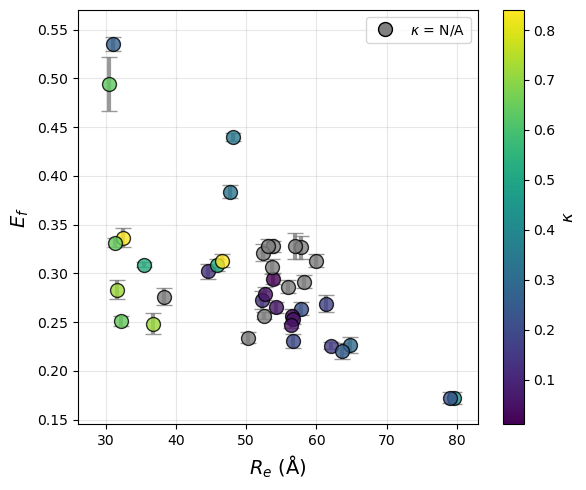

In [15]:
# Separate constructs into library (<34) and designed (>34)
library_constructs = construct_stats[construct_stats['construct'] < 34].copy()
designed_constructs = construct_stats[construct_stats['construct'] > 34].copy()

# Combine all constructs for overall analysis
all_constructs = construct_stats[(construct_stats['construct'] < 34) | 
                                 (construct_stats['construct'] > 34)].copy()

# Create plot
fig, ax = plt.subplots(figsize=(6, 5))

# Separate constructs by kappa value
positive_kappa = all_constructs[all_constructs['kappa'] > 0].copy()
negative_kappa = all_constructs[all_constructs['kappa'] <= 0].copy()

# Create colormap based on positive kappa values only
if len(positive_kappa) > 0:
    norm = plt.Normalize(vmin=positive_kappa['kappa'].min(), vmax=positive_kappa['kappa'].max())
    cmap = plt.cm.viridis

    # Plot constructs with kappa > 0 colored by kappa
    for idx, row in positive_kappa.iterrows():
        color = cmap(norm(row['kappa']))
        ax.errorbar(row['re'], row['Ef_cell'], 
                   yerr=row['Ef_cell_std'], fmt='o', 
                   markeredgecolor='black', alpha=0.8, color=color, capsize=6, linewidth=3, ms=10,
                   ecolor='grey', zorder=3)

# Plot constructs with kappa <= 0 in grey
for idx, row in negative_kappa.iterrows():
    ax.errorbar(row['re'], row['Ef_cell'], 
               yerr=row['Ef_cell_std'], fmt='o', 
               markeredgecolor='black', alpha=0.8, color='grey', capsize=6, linewidth=3, ms=10,
               ecolor='grey', zorder=3)

# Add colorbar only for positive kappa values
if len(positive_kappa) > 0:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r'$\kappa$', fontsize=12)

plt.xlim(26, 83)
plt.ylim(.145, .57)
ax.set_xlabel(r'$R_e$ (Å)', fontsize=14)
ax.set_ylabel(r'$E_{f}$', fontsize=14)
ax.grid(True, alpha=0.3)

# Add legend for kappa categories
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', 
           markeredgecolor='black', markersize=10, label=r'$\kappa$ = N/A'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('Figure_graphs/FigSI/Ef_vs_Re_all_kappa.svg')
plt.show()

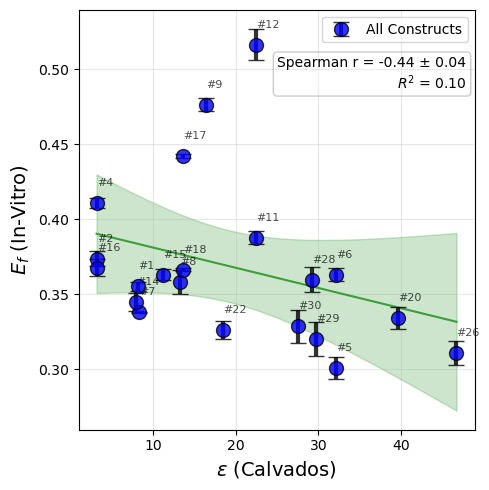

Plotted 21 constructs
Spearman r = -0.44 ± 0.04
Linear regression: slope = -0.0013, intercept = 0.3946
R^2 = 0.10


In [44]:
# Filter for constructs that have both values
plot_constructs = construct_stats[
    construct_stats['Ef_invitro'].notna() & 
    construct_stats['calvados_epsilon'].notna()
].copy()

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_y = []
    
    for idx, row in plot_constructs.iterrows():
        # Sample from normal distribution for Ef_invitro
        sampled_y_val = np.random.normal(row['Ef_invitro'], row['Ef_invitro_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation for this iteration
    spearman_r_sample, _ = sp_stats.spearmanr(plot_constructs['calvados_epsilon'], sampled_y)
    spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

# Linear regression
x_data = plot_constructs['calvados_epsilon'].values
y_data = plot_constructs['Ef_invitro'].values

popt, pcov = curve_fit(linear_function, x_data, y_data)
slope, intercept = popt

# Calculate R-squared and residual standard error
residuals = y_data - linear_function(x_data, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
n = len(x_data)
dof = n - 2
residual_std_error = np.sqrt(ss_res / dof)
t_val = t_dist.ppf(0.975, dof)

# Generate line for plotting
x_fit = np.linspace(x_data.min() - 0.05, x_data.max() + 0.05, 200)
y_fit = linear_function(x_fit, slope, intercept)

# 95% confidence interval for the prediction
se_line = residual_std_error * np.sqrt(1/n + (x_fit - np.mean(x_data))**2 / np.sum((x_data - np.mean(x_data))**2))
y_upper = y_fit + t_val * se_line
y_lower = y_fit - t_val * se_line

# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot confidence band first
ax.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2, zorder=1)

# Plot fit line
ax.plot(x_fit, y_fit, color='green', linewidth=1.5, alpha=0.7, zorder=2)

# Plot data points
ax.errorbar(plot_constructs['calvados_epsilon'], plot_constructs['Ef_invitro'], 
           yerr=plot_constructs['Ef_invitro_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='blue', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='All Constructs', zorder=3)

# Add labels for each construct
for idx, row in plot_constructs.iterrows():
    ax.text(row['calvados_epsilon'], row['Ef_invitro'] + 0.01, f"#{int(row['construct'])}", 
           fontsize=8, ha='left', va='bottom', alpha=0.7)

ax.set_xlabel(r'$\epsilon$ (Calvados)', fontsize=14)
ax.set_ylabel(r'$E_{f}$ (In-Vitro)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

ax.text(0.98, 0.89, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.tight_layout()
#plt.savefig('Figure_graphs/FigSI/Ef_invitro_vs_epsilon.svg')
plt.show()

print(f"Plotted {len(plot_constructs)} constructs")
print(f"Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}")
print(f"Linear regression: slope = {slope:.4f}, intercept = {intercept:.4f}")
print(f"R^2 = {r_squared:.2f}")

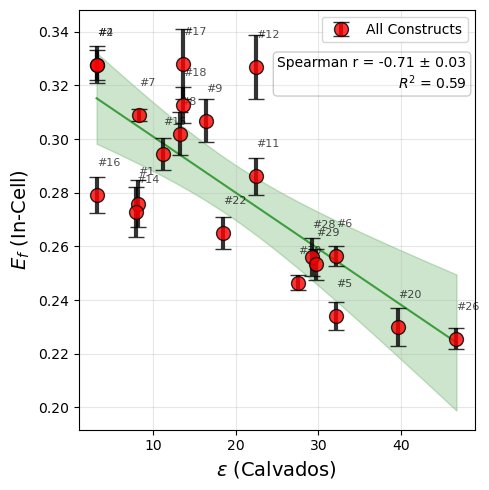

Plotted 21 constructs (with Ef_invitro data)
Spearman r = -0.71 ± 0.03
Linear regression: slope = -0.0021, intercept = 0.3219
R^2 = 0.59


In [45]:
# Filter for constructs that have Ef_cell, calvados_epsilon, AND Ef_invitro values
plot_constructs = construct_stats[
    construct_stats['Ef_cell'].notna() & 
    construct_stats['calvados_epsilon'].notna() &
    construct_stats['Ef_invitro'].notna()
].copy()

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_y = []
    
    for idx, row in plot_constructs.iterrows():
        # Sample from normal distribution for Ef_cell
        sampled_y_val = np.random.normal(row['Ef_cell'], row['Ef_cell_std'])
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation for this iteration
    spearman_r_sample, _ = sp_stats.spearmanr(plot_constructs['calvados_epsilon'], sampled_y)
    spearman_values.append(spearman_r_sample)

# Calculate mean and std of Spearman correlations
spearman_r_mean = np.mean(spearman_values)
spearman_r_std = np.std(spearman_values)

# Linear regression
x_data = plot_constructs['calvados_epsilon'].values
y_data = plot_constructs['Ef_cell'].values

popt, pcov = curve_fit(linear_function, x_data, y_data)
slope, intercept = popt

# Calculate R-squared and residual standard error
residuals = y_data - linear_function(x_data, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
n = len(x_data)
dof = n - 2
residual_std_error = np.sqrt(ss_res / dof)
t_val = t_dist.ppf(0.975, dof)

# Generate line for plotting
x_fit = np.linspace(x_data.min() - 0.05, x_data.max() + 0.05, 200)
y_fit = linear_function(x_fit, slope, intercept)

# 95% confidence interval for the prediction
se_line = residual_std_error * np.sqrt(1/n + (x_fit - np.mean(x_data))**2 / np.sum((x_data - np.mean(x_data))**2))
y_upper = y_fit + t_val * se_line
y_lower = y_fit - t_val * se_line

# Create plot
fig, ax = plt.subplots(figsize=(5, 5))

# Plot confidence band first
ax.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2, zorder=1)

# Plot fit line
ax.plot(x_fit, y_fit, color='green', linewidth=1.5, alpha=0.7, zorder=2)

# Plot data points
ax.errorbar(plot_constructs['calvados_epsilon'], plot_constructs['Ef_cell'], 
           yerr=plot_constructs['Ef_cell_std'], fmt='o', 
           markeredgecolor='black', alpha=0.8, color='red', capsize=6, linewidth=3, ms=10,
           ecolor='black', label='All Constructs', zorder=3)

# Add labels for each construct
for idx, row in plot_constructs.iterrows():
    ax.text(row['calvados_epsilon'], row['Ef_cell'] + 0.01, f"#{int(row['construct'])}", 
           fontsize=8, ha='left', va='bottom', alpha=0.7)

ax.set_xlabel(r'$\epsilon$ (Calvados)', fontsize=14)
ax.set_ylabel(r'$E_{f}$ (In-Cell)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True, fontsize=10)

ax.text(0.98, 0.89, f'Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}\n$R^2$ = {r_squared:.2f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.tight_layout()
#plt.savefig('Figure_graphs/FigSI/Ef_cell_vs_epsilon.svg')
plt.show()

print(f"Plotted {len(plot_constructs)} constructs (with Ef_invitro data)")
print(f"Spearman r = {spearman_r_mean:.2f} ± {spearman_r_std:.2f}")
print(f"Linear regression: slope = {slope:.4f}, intercept = {intercept:.4f}")
print(f"R^2 = {r_squared:.2f}")